<br>
<font>
<div dir=ltr align=center>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Arash Marioriyad<br>
    Spring 2026<br>
<font color=3C99D size=5>
    Practical HomeWork 2<br>
    Tic-Tac-Toe<br>
<font color=696880 size=4>
    Fateme Masoumian

`Full Name:`

`Student ID:`

# **AI Practical Assignment : Adversarial Search with Minimax and Alpha-Beta Pruning**

Welcome to your practical assignment! The goal of this exercise is to understand and implement **adversarial search algorithms** , which are fundamental to creating AI for two-player, zero-sum games like Tic-Tac-Toe, Chess, or Go.

In this notebook, you will:
1.  **Create and Visualize a Game Tree**: Understand how a game can be represented as a tree of possible moves.
2.  **Implement the Minimax Algorithm**: Write the code for the optimal recursive strategy that determines the best move by assuming the opponent plays optimally as well.
3.  **Implement Alpha-Beta Pruning**: Optimize the Minimax algorithm by intelligently "pruning" branches of the game tree that don't need to be explored.
4.  **Analyze Algorithm Performance**: Investigate how factors like move ordering can dramatically affect the efficiency of Alpha-Beta pruning.

This assignment will build directly on the concepts discussed in the lecture slides. Let's get started!


## Setup & Imports

In [6]:
# Setup: Importing Necessary Libraries
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import string

np.random.seed(42)

# **Part 1: The Game Tree**

An adversarial game can be modeled as a tree. The **root** of the tree is the current state of the game. The **nodes** are states that can be reached, and the **edges** represent moves. The **leaf nodes** are terminal states, each with a **utility value** or score (e.g., +1 for a win, -1 for a loss, 0 for a draw).

Our goal is to find the best possible move from the current state. We will work with two players:
*   **MAX player (▲)**: Tries to maximize the score.
*   **MIN player (▼)**: Tries to minimize the score.

We'll start by creating a function to generate a random game tree and another function to visualize it.

## Tree Creation and Visualization

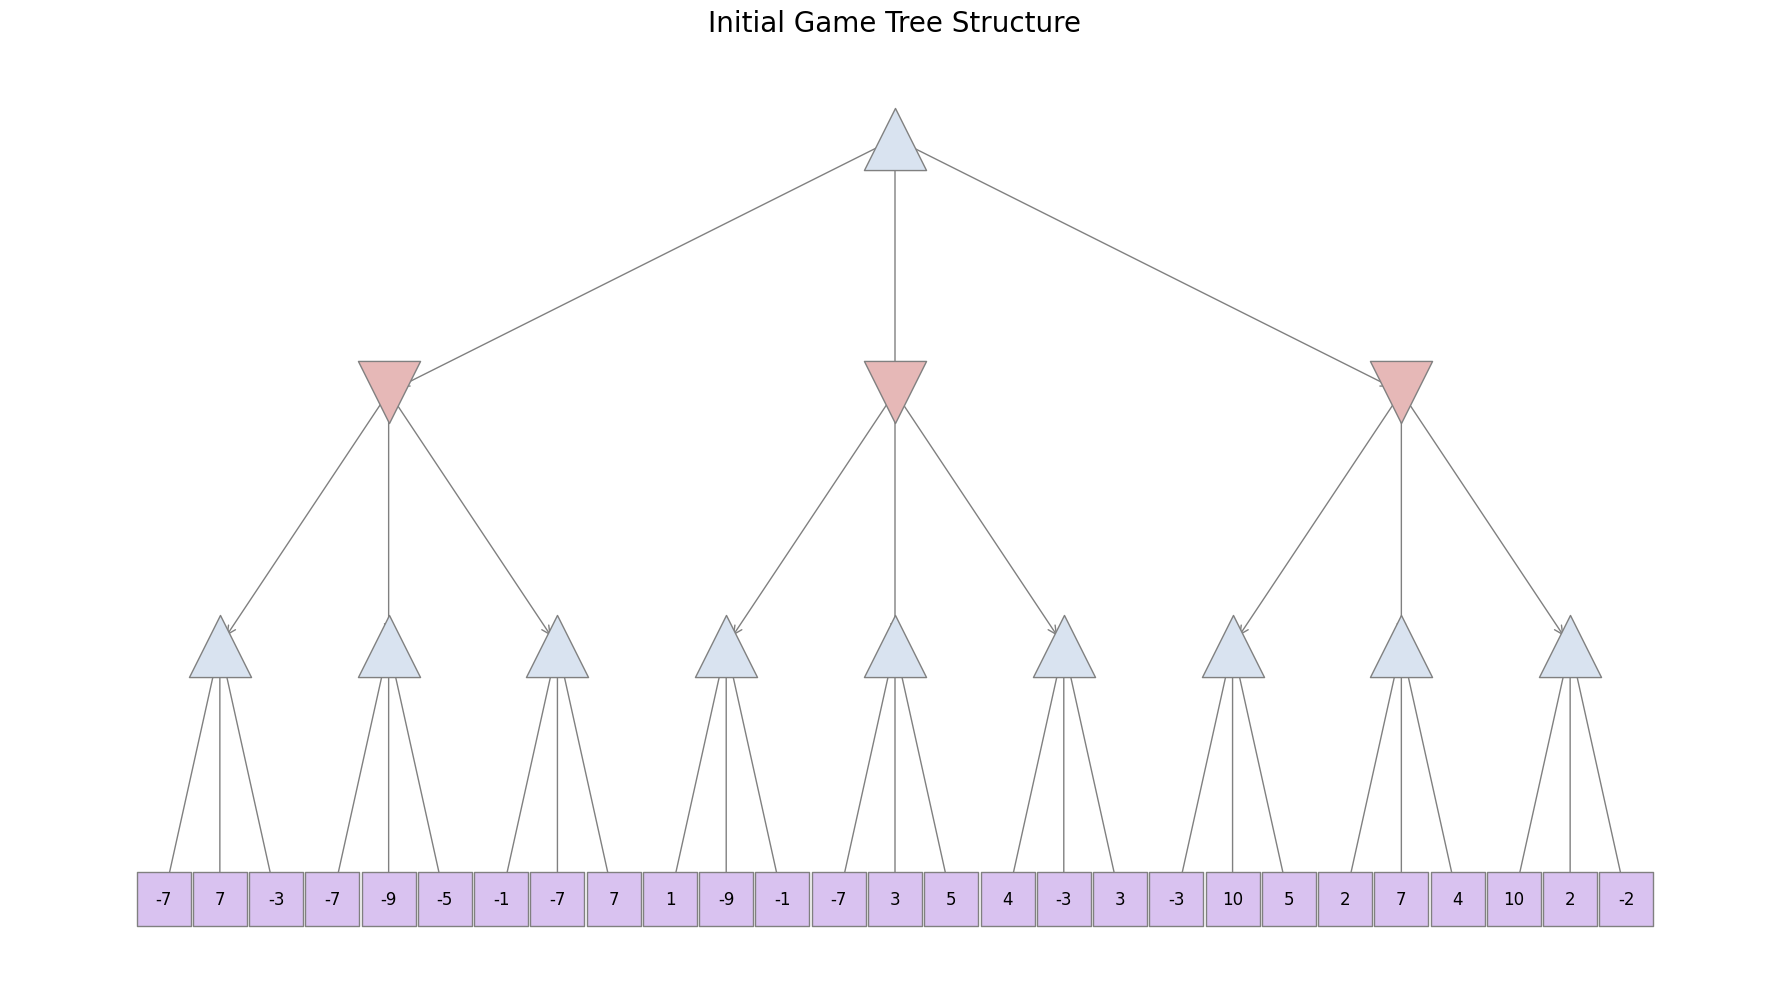

In [12]:
def create_game_tree(depth, branching_factor):
    """Creates a game tree using NetworkX."""
    G = nx.DiGraph()
    
    def add_nodes_recursively(node_id, current_depth):
        G.add_node(node_id, depth=current_depth)
        
        # If it's a leaf node, assign a random utility value
        if current_depth == depth:
            G.nodes[node_id]['value'] = np.random.randint(-10, 11)
            return

        # Otherwise, create children and recurse
        for i in range(branching_factor):
            child_id = f"{node_id}-{i}"
            G.add_edge(node_id, child_id)
            add_nodes_recursively(child_id, current_depth + 1)

    add_nodes_recursively("0", 0)
    return G

def hierarchy_pos(G, root):
    """Custom hierarchical top-down layout for trees to avoid graphviz dependencies."""
    pos = {}
    dfs_nodes = list(nx.dfs_preorder_nodes(G, root))
    leaves_ordered = [n for n in dfs_nodes if G.out_degree(n) == 0]
    
    # Assign horizontal positions to leaves first
    for i, leaf in enumerate(leaves_ordered):
        pos[leaf] = (i * 2, -G.nodes[leaf]['depth'] * 2)
        
    # Assign horizontal positions to parents based on the average of their children
    for node in reversed(dfs_nodes):
        if G.out_degree(node) > 0:
            children = list(G.successors(node))
            x = sum(pos[c][0] for c in children) / len(children)
            pos[node] = (x, -G.nodes[node]['depth'] * 2)
    return pos

def plot_game_tree(G, node_values=None, visited_nodes=None, title="Game Tree"):
    """Visualizes the game tree vertically with clear MAX/MIN/Leaf shapes."""
    plt.figure(figsize=(18, 10)) # Large vertical box
    
    pos = hierarchy_pos(G, "0")

    # Separate nodes by type
    max_nodes = [n for n, d in G.nodes(data='depth') if d % 2 == 0 and G.out_degree(n) > 0]
    min_nodes = [n for n, d in G.nodes(data='depth') if d % 2 == 1 and G.out_degree(n) > 0]
    leaf_nodes = [n for n in G.nodes() if G.out_degree(n) == 0]
    
    # Helper to filter visible nodes
    def get_nodes(n_list, visited):
        if visited is None: return n_list
        return [n for n in n_list if n in visited]
        
    def get_unvisited(n_list, visited):
        if visited is None: return []
        return [n for n in n_list if n not in visited]

    # Draw edges first so they are behind nodes
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='->', arrowsize=15, edge_color='gray')

    # Unvisited Nodes (Faded out)
    nx.draw_networkx_nodes(G, pos, nodelist=get_unvisited(max_nodes, visited_nodes), node_shape='^', node_color='#e0e0e0', node_size=1500, edgecolors='gray')
    nx.draw_networkx_nodes(G, pos, nodelist=get_unvisited(min_nodes, visited_nodes), node_shape='v', node_color='#e0e0e0', node_size=1500, edgecolors='gray')
    nx.draw_networkx_nodes(G, pos, nodelist=get_unvisited(leaf_nodes, visited_nodes), node_shape='s', node_color='#e0e0e0', node_size=1200, edgecolors='gray')

    # Visited Nodes (Colored)
    nx.draw_networkx_nodes(G, pos, nodelist=get_nodes(max_nodes, visited_nodes), node_shape='^', node_color='#d9e3f0', node_size=2000, edgecolors='gray')
    nx.draw_networkx_nodes(G, pos, nodelist=get_nodes(min_nodes, visited_nodes), node_shape='v', node_color='#e6b8b7', node_size=2000, edgecolors='gray')
    nx.draw_networkx_nodes(G, pos, nodelist=get_nodes(leaf_nodes, visited_nodes), node_shape='s', node_color='#d9c2f0', node_size=1500, edgecolors='gray')

    # Prepare labels
    labels = {}
    for n in G.nodes():
        if G.out_degree(n) == 0: # Leaf node
            labels[n] = G.nodes[n]['value']
        elif node_values and n in node_values: # Visited internal node
            labels[n] = f"{node_values[n]}"
        else:
            labels[n] = "" # Leave empty if no value yet

    nx.draw_networkx_labels(G, pos, labels, font_size=12, font_color='black')
    
    plt.title(title, fontsize=20, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Rational size for clear vertical visualization
DEPTH = 3
BRANCHING_FACTOR = 3
game_tree = create_game_tree(DEPTH, BRANCHING_FACTOR)

# Plot the initial tree structure
plot_game_tree(game_tree, title="Initial Game Tree Structure")


# **Part 2: The Minimax Algorithm**

The Minimax algorithm performs a complete depth-first search of the game tree.
- **MAX player** chooses the move that leads to the outcome with the highest value.
- **MIN player** chooses the move that leads to the outcome with the lowest value.

Each node's value is determined by the values of its children. For a MAX node, its value is the maximum of its children's values. For a MIN node, its value is the minimum of its children's values.

**Your Task:** Implement the `minimax` function below. The function should be recursive and explore the entire tree to find the optimal value from the root. It should also track which nodes it visits.

## Minimax Implementation

Optimal value at root (Minimax): 8
Total nodes watched by Minimax: 40 out of 40


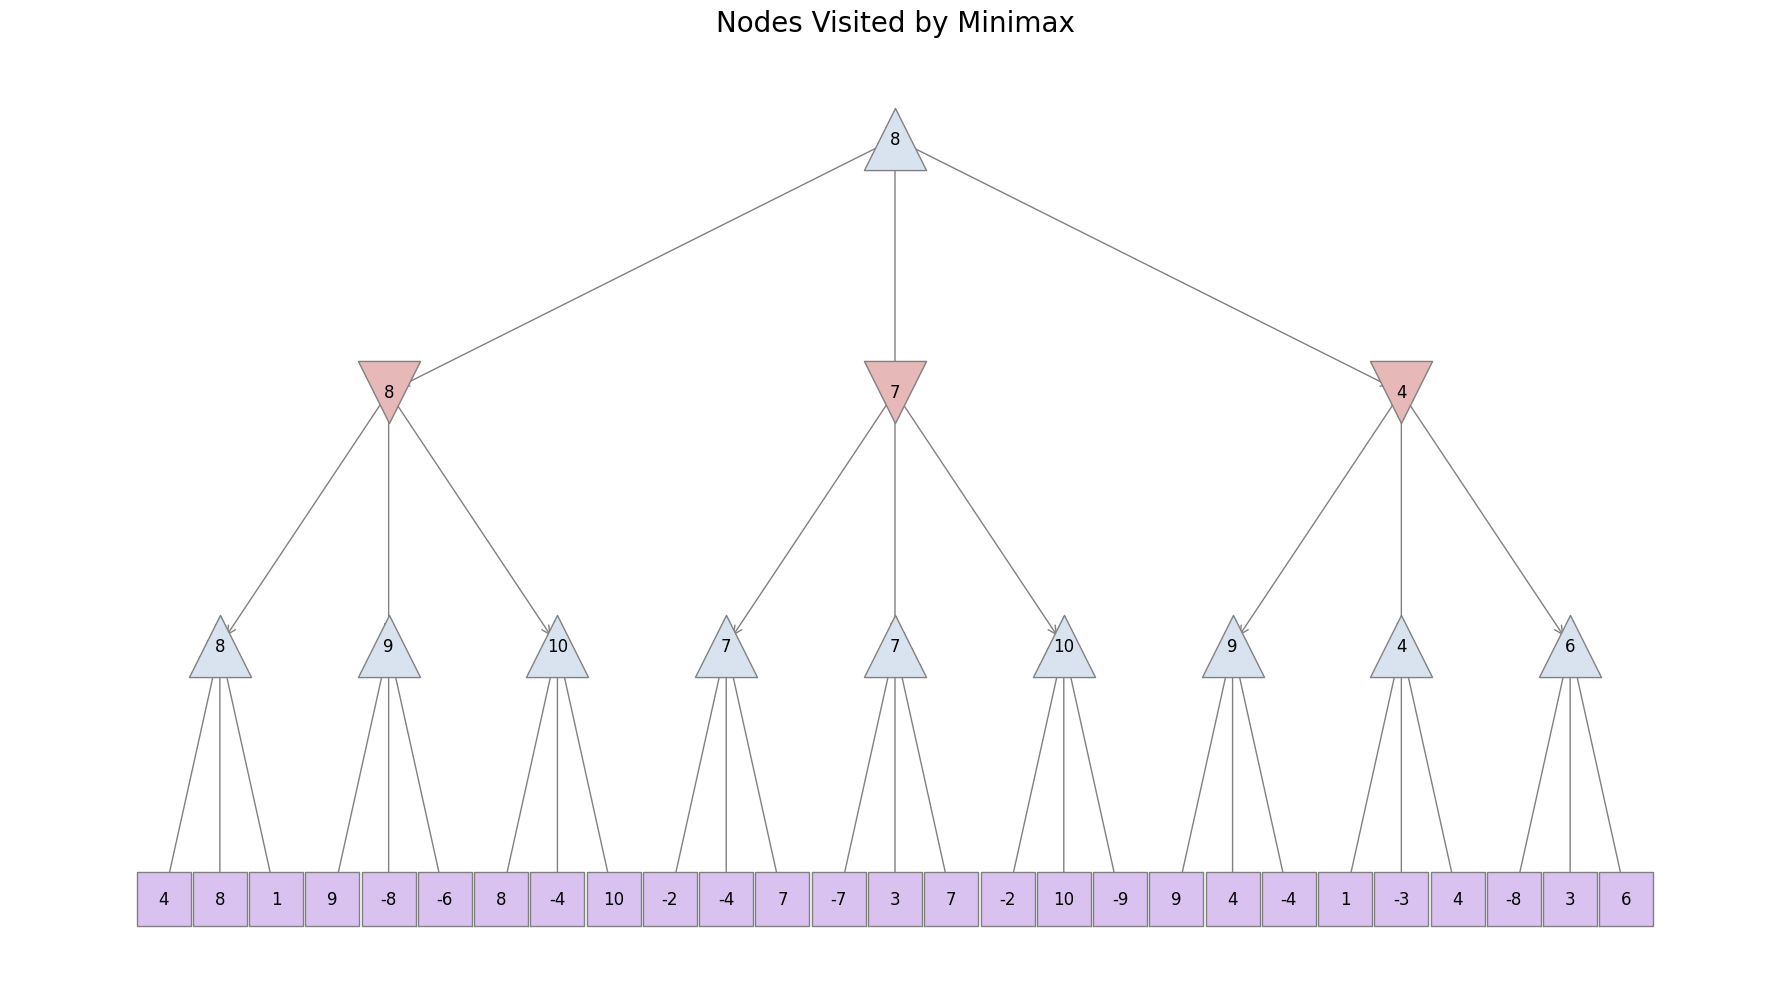

In [9]:
def minimax(graph, node, is_max_player, visited_nodes, node_values):
    """Performs the Minimax algorithm on a game tree."""
    # We mark the node as visited for visualization purposes
    visited_nodes.add(node)
    
    # TODO: Implement the complete Minimax logic here.
    # 
    # Instructions:
    # 1. Base Case: Check if the current node is a leaf node (i.e., graph.out_degree(node) == 0).
    #    If it is, retrieve its 'value' from the graph, store it in node_values[node], and return the value.
    #    Hint: value = graph.nodes[node]['value']
    # 
    # 2. MAX Player Turn: If `is_max_player` is True:
    #    - Initialize a variable for the best value (e.g., -float('inf')).
    #    - Iterate over all children of the node (using graph.successors(node)).
    #    - Recursively call `minimax` for each child.
    #    - Update the best value found so far.
    #    - Store the final best value in `node_values[node]` and return it.
    # 
    # 3. MIN Player Turn: If `is_max_player` is False:
    #    - Initialize a variable for the best value (e.g., float('inf')).
    #    - Iterate over all children, recursively call `minimax`, and update the best value.
    #    - Store the final best value in `node_values[node]` and return it.
    
    pass

# Run the Minimax algorithm
visited_minimax = set()
values_minimax = {}
root_value_minimax = minimax(game_tree, "0", True, visited_minimax, values_minimax)

print(f"Optimal value at root (Minimax): {root_value_minimax}")
print(f"Total nodes watched by Minimax: {len(visited_minimax)} out of {len(game_tree.nodes)}")

# Visualize the result
plot_game_tree(game_tree, node_values=values_minimax, visited_nodes=visited_minimax, title="Nodes Visited by Minimax")

# **Part 3: Alpha-Beta Pruning**

As you can see, Minimax visits every single node in the tree. This is very inefficient for large games (Time Complexity: $O(b^m)$). **Alpha-Beta Pruning** is an optimization that returns the same result as Minimax but avoids searching parts of the tree it knows can't influence the final decision.

It maintains two values:
- **`alpha`**: The best value (highest) found so far for **MAX** along the path from the root to the current node.
- **`beta`**: The best value (lowest) found so far for **MIN** along the path from the root to the current node.

The key pruning condition is: **`beta <= alpha`**.
- If a **MAX** node encounters a child value greater than or equal to `beta`, it can stop searching its other children. 
- If a **MIN** node encounters a child value less than or equal to `alpha`, it can stop searching.

**Your Task:** Implement the `alpha_beta_search` function. Pay close attention to how `alpha` and `beta` are updated and passed down.

## Alpha-Beta Implementation

Optimal value at root (Alpha-Beta): 8
Total nodes watched by Alpha-Beta: 24
Nodes pruned (saved): 16


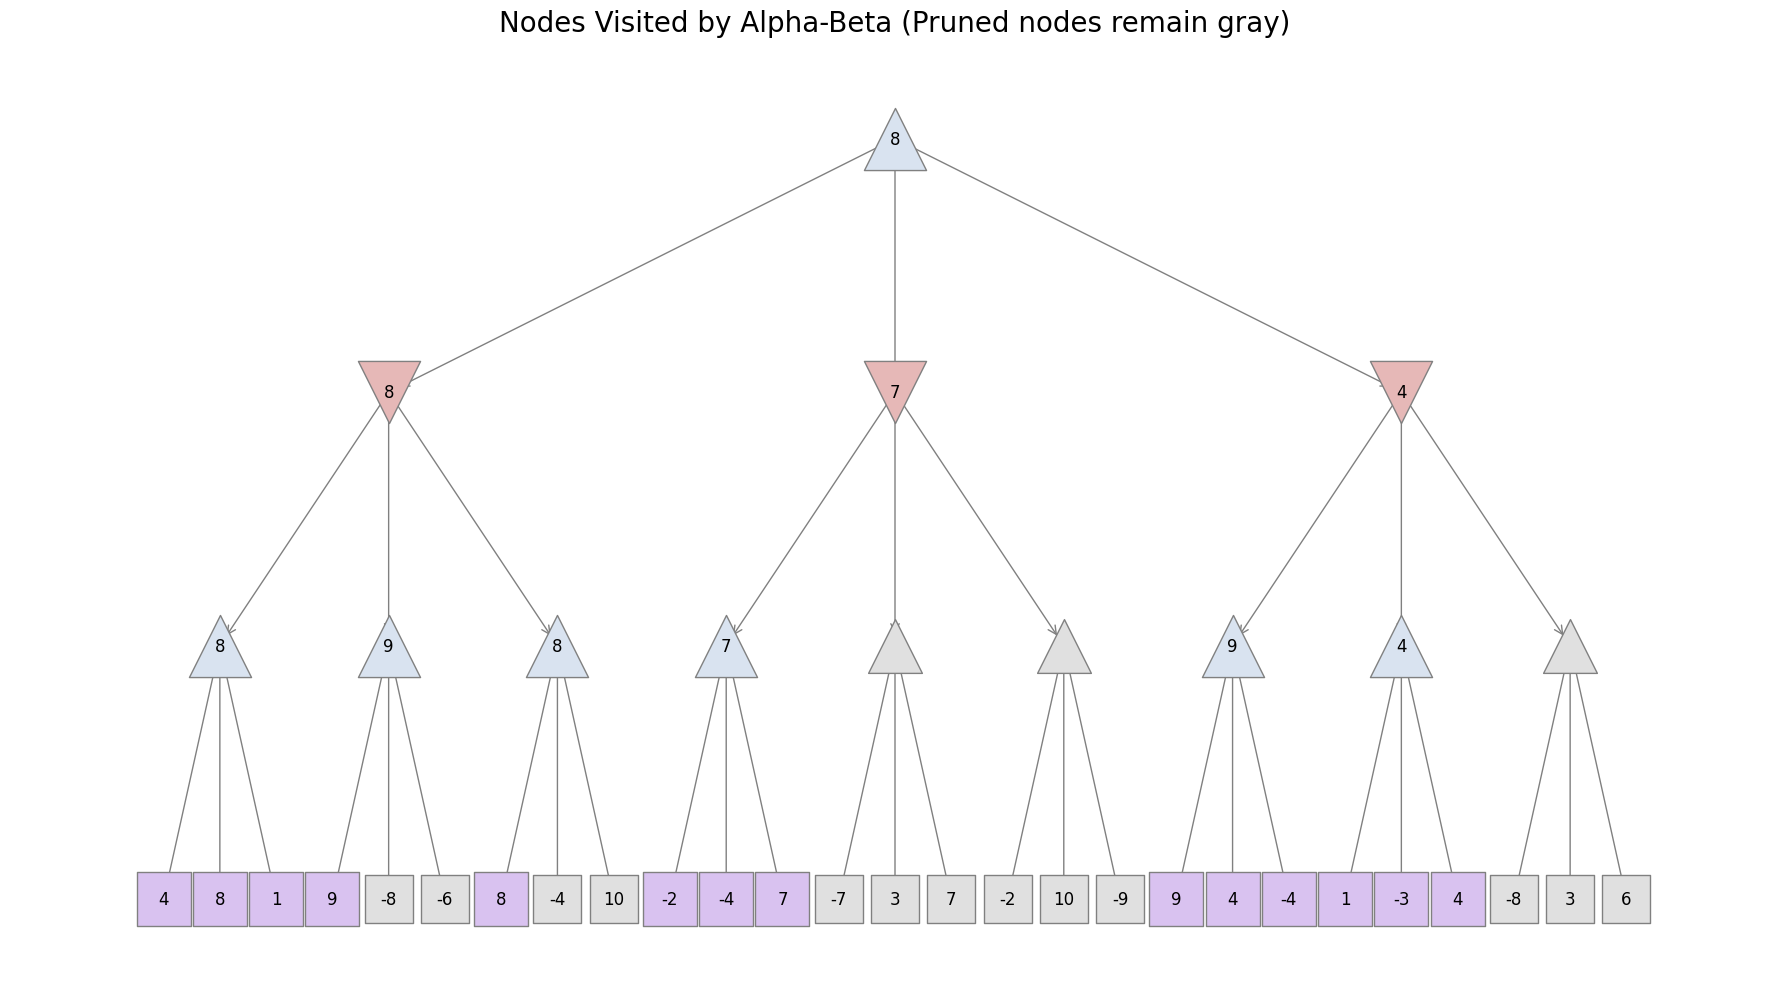

In [10]:
def alpha_beta_search(graph, node, alpha, beta, is_max_player, visited_nodes, node_values):
    """Performs the Alpha-Beta Pruning search on a game tree."""
    visited_nodes.add(node)

    # TODO: Implement the Alpha-Beta pruning logic here.
    #
    # Instructions:
    # 1. Base Case: Check for a terminal node (leaf) and return its value just like in Minimax.
    #
    # 2. MAX Player Turn:
    #    - Iterate over children. Call alpha_beta_search recursively.
    #    - Update best_value and `alpha`.
    #    - PRUNING CONDITION: If beta <= alpha, break out of the loop (prune the remaining branches).
    #
    # 3. MIN Player Turn:
    #    - Iterate over children. Call alpha_beta_search recursively.
    #    - Update best_value and `beta`.
    #    - PRUNING CONDITION: If beta <= alpha, break out of the loop.
    #
    # Don't forget to store the calculated value in `node_values[node]` before returning!
    
    pass

# Run the Alpha-Beta algorithm
visited_ab = set()
values_ab = {}
root_value_ab = alpha_beta_search(game_tree, "0", -float('inf'), float('inf'), True, visited_ab, values_ab)

print(f"Optimal value at root (Alpha-Beta): {root_value_ab}")
print(f"Total nodes watched by Alpha-Beta: {len(visited_ab)}")
print(f"Nodes pruned (saved): {len(visited_minimax) - len(visited_ab)}")

# Visualize the result
plot_game_tree(game_tree, node_values=values_ab, visited_nodes=visited_ab, title="Nodes Visited by Alpha-Beta (Pruned nodes remain gray)")


# **Part 4: The Importance of Move Ordering**

The performance of Alpha-Beta pruning is highly dependent on **move ordering**. If the algorithm explores the best moves first, it can achieve maximal pruning. If it explores the worst moves first, it may not prune any branches at all.

With "perfect ordering", the time complexity can be reduced from $O(b^m)$ to roughly $O(b^{m/2})$, effectively doubling the solvable search depth.

**Your Task:** Analyze the code and the output below to see how perfect move ordering further reduces the number of visited nodes.


##  Move Ordering

--- Algorithm Performance Comparison (Nodes Watched) ---
1. Minimax visited: 40 nodes.
2. Alpha-Beta (random order) visited: 24 nodes.
3. Alpha-Beta (optimal order) visited: 20 nodes.



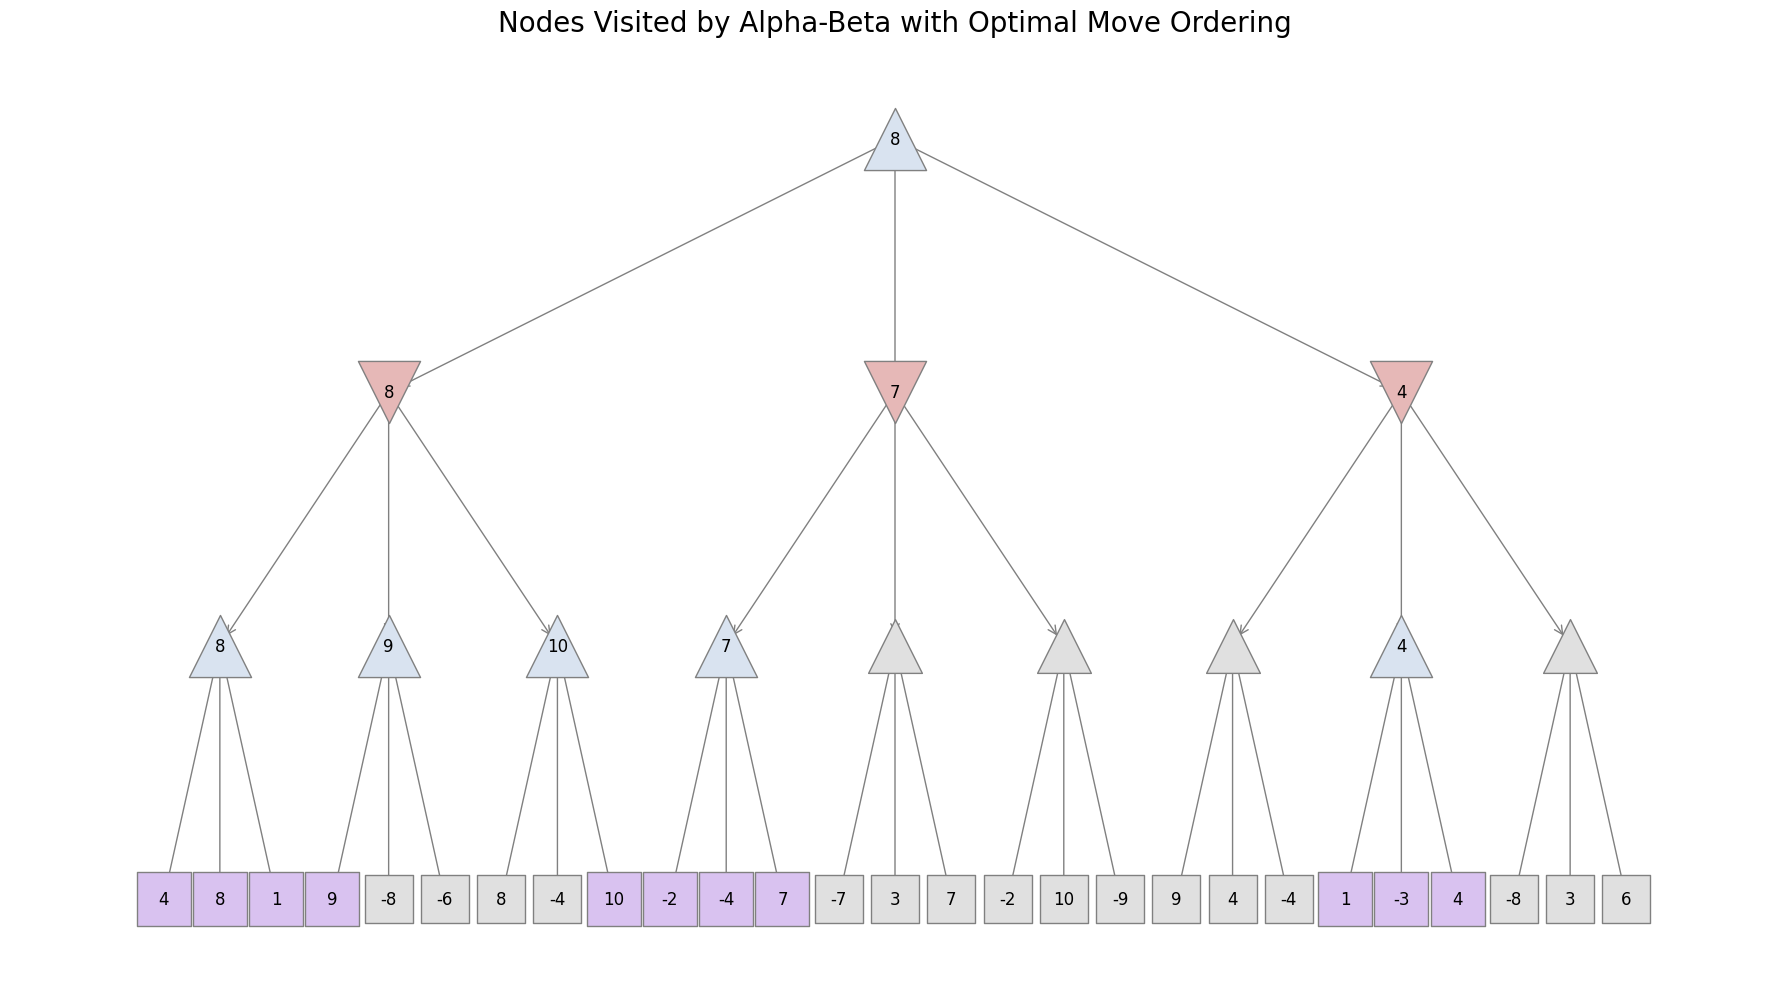

In [11]:
def get_ordered_children(graph, node, is_max_player):
    """Sorts children to demonstrate move ordering impact."""
    children = list(graph.successors(node))
    
    # TODO: Sort the `children` list optimally.
    #
    # Instructions:
    # We want to use the perfect values calculated from the standard minimax search 
    # to simulate a perfect heuristic.
    #
    # - Retrieve the true value of each child from the `values_minimax` dictionary.
    # - If `is_max_player` is True, sort the children in DESCENDING order (highest value first).
    # - If `is_max_player` is False, sort the children in ASCENDING order (lowest value first).
    #
    # Hint: You can use children.sort(key=lambda child: ..., reverse=...)
    
    pass

def alpha_beta_ordered(graph, node, alpha, beta, is_max_player, visited_nodes, node_values):
    """Alpha-Beta search that uses a specific move ordering strategy."""
    visited_nodes.add(node)

    # TODO: Implement the ordered Alpha-Beta search.
    #
    # Instructions:
    # This code should be nearly identical to your `alpha_beta_search` implementation above.
    # The CRITICAL difference is that instead of looping through `graph.successors(node)`,
    # you must fetch the children by calling your `get_ordered_children` function first, 
    # and then loop through that sorted list.
    
    pass
        
visited_ab_ordered = set()
values_ab_ordered = {}
root_value_ab_ordered = alpha_beta_ordered(game_tree, "0", -float('inf'), float('inf'), True, visited_ab_ordered, values_ab_ordered)

print("--- Algorithm Performance Comparison (Nodes Watched) ---")
print(f"1. Minimax visited: {len(visited_minimax)} nodes.")
print(f"2. Alpha-Beta (random order) visited: {len(visited_ab)} nodes.")
print(f"3. Alpha-Beta (optimal order) visited: {len(visited_ab_ordered)} nodes.\n")

# Visualize the result
plot_game_tree(game_tree, node_values=values_ab_ordered, visited_nodes=visited_ab_ordered, title="Nodes Visited by Alpha-Beta with Optimal Move Ordering")

## **Part 5: Theory & Evaluation Questions**

### **Q1: Did the final root value change between the Minimax, standard Alpha-Beta, and ordered Alpha-Beta algorithms? Why is this significant?**

*Your Answer Here*

### **Q2: Compare the visualization "Nodes Visited by Alpha-Beta" with the "Optimal Move Ordering" visualization. Find a specific node where the optimally-ordered search pruned more branches than the standard search. Explain why.**

*Your Answer Here*

### **Q3: In a real game like Chess, we can't know the "perfect" move ordering ahead of time. What are some practical strategies (heuristics) a game AI could use to guess which moves are better and should be explored first?**

*Your Answer Here*


# **Part 6: Practical Application - Tic-Tac-Toe**
Now that we understand how Minimax and Alpha-Beta pruning work on synthetic trees, let's apply them to a real game! 
Tic-Tac-Toe is a perfect information game with a small enough state space that we can search the entire game tree to the very end (terminal states) without needing a depth limit or a heuristic evaluation function.

In this section, you will:
1. Familiarize yourself with the Tic-Tac-Toe environment.
2. Implement a Minimax agent to play as 'X' or 'O'.
3. Play a game against your own unbeatable AI!

## The Enviroment

In [14]:
# --- Tic-Tac-Toe Environment ---
# We represent the board as a simple list of 9 strings: 'X', 'O', or ' ' (empty)

def print_board(board):
    """Prints the current state of the board."""
    print("\n")
    for i in range(0, 9, 3):
        print(f" {board[i]} | {board[i+1]} | {board[i+2]} ")
        if i < 6:
            print("---+---+---")
    print("\n")

def get_available_moves(board):
    """Returns a list of indices representing available moves."""
    return [i for i, spot in enumerate(board) if spot == ' ']

def check_winner(board):
    """
    Checks if there is a winner. 
    Returns 'X', 'O', 'Tie', or None if the game is still ongoing.
    """
    win_combinations = [
        [0, 1, 2], [3, 4, 5], [6, 7, 8], # Rows
        [0, 3, 6], [1, 4, 7], [2, 5, 8], # Columns
        [0, 4, 8], [2, 4, 6]             # Diagonals
    ]
    
    for combo in win_combinations:
        if board[combo[0]] == board[combo[1]] == board[combo[2]] and board[combo[0]] != ' ':
            return board[combo[0]]
            
    if ' ' not in board:
        return 'Tie'
        
    return None

# Test the environment
sample_board = ['X', 'O', 'X', ' ', 'O', ' ', ' ', 'X', ' ']
print("Sample Board:")
print_board(sample_board)
print(f"Available moves: {get_available_moves(sample_board)}")
print(f"Winner: {check_winner(sample_board)}")

Sample Board:


 X | O | X 
---+---+---
   | O |   
---+---+---
   | X |   


Available moves: [3, 5, 6, 8]
Winner: None


## The AI Agent

In [15]:
def tictactoe_minimax(board, is_maximizing, ai_player, human_player):
    """
    Returns the optimal score for the current board state.
    """
    winner = check_winner(board)
    
    # Base cases: Evaluate terminal states
    if winner == ai_player:
        return 1  # AI wins
    elif winner == human_player:
        return -1 # Human wins
    elif winner == 'Tie':
        return 0  # Draw
        
    #TODO
    
    if is_maximizing:
        best_score = -float('inf')
        
        # TODO: Iterate through all available moves using get_available_moves(board)
        # For each move:
        # 1. Apply the move to the board for the ai_player
        # 2. Recursively call tictactoe_minimax (remember: it will be the minimizing player's turn next)
        # 3. Undo the move (reset the board spot to ' ')
        # 4. Update best_score using the max() function
        
        pass # Remove this pass when you write your code
        
        return best_score
        
    else: # Minimizing (Human's simulated turn)
        best_score = float('inf')
        
        # TODO: Iterate through all available moves using get_available_moves(board)
        # For each move:
        # 1. Apply the simulated move to the board for the human_player
        # 2. Recursively call tictactoe_minimax (remember: it will be the maximizing player's turn next)
        # 3. Undo the move (reset the board spot to ' ')
        # 4. Update best_score using the min() function
        
        pass # Remove this pass when you write your code
        
        return best_score
        

def get_best_move(board, ai_player, human_player):
    """Uses minimax to find the best move index for the AI."""
    best_score = -float('inf')
    best_move = None
    
    for move in get_available_moves(board):
        # Try the move
        board[move] = ai_player
        # Calculate the score for this move
        score = tictactoe_minimax(board, False, ai_player, human_player)
        # Undo the move
        board[move] = ' '
        
        if score > best_score:
            best_score = score
            best_move = move
            
    return best_move

## Play the Game!

In [ ]:
def play_game():
    """Interactive loop to play against the AI."""
    board = [' '] * 9
    human_player = 'X'
    ai_player = 'O'
    
    print("Welcome to Tic-Tac-Toe! You are 'X', AI is 'O'.")
    print("Positions are 0-8, reading left-to-right, top-to-bottom.")
    print_board([str(i) for i in range(9)]) # Show position numbers
    
    while True:
        # Human Turn
        valid_move = False
        while not valid_move:
            try:
                move = int(input("Enter your move (0-8): "))
                
                # TODO : Process Human Move
                # 1. Check if the 'move' is in the list of available moves.
                #    (Hint: use get_available_moves)
                # 2. If it is, update the board at 'move' with 'human_player' 
                #    and set valid_move to True.
                # 3. If it is NOT, print "Invalid move. Try again."
                pass # Remove this pass when you write your code
                
            except ValueError:
                print("Please enter a valid number.")
                
        print_board(board)
        
        # TODO : Check for Game Over (After Human Turn)
        # Call check_winner(board). If there is a winner or a tie 
        # (if it doesn't return None), break out of the while loop.
        pass # Remove this pass when you write your code
            
        # AI Turn
        print("AI is thinking...")
        
        # TODO : Process AI Move
        # 1. Find the best move for the AI using the get_best_move(...) function.
        # 2. Apply the returned AI move to the board for the 'ai_player'.
        # 3. Print a message showing where the AI played (e.g., f"AI plays at position {ai_move}")
        
        pass # Remove this pass when you write your code
        
        print_board(board)
        
        # TODO : Check for Game Over (After AI Turn)
        # Check if the game is over again. If it is, break out of the loop.
        
        pass # Remove this pass when you write your code

    # Game Over Display
    winner = check_winner(board)
    if winner == 'Tie':
        print("It's a Tie!")
    elif winner == human_player:
        print("You won! (Wait, this shouldn't be possible...)")
    else:
        print("AI wins! Better luck next time.")

# Start the game!
play_game()

Welcome to Tic-Tac-Toe! You are 'X', AI is 'O'.
Positions are 0-8, reading left-to-right, top-to-bottom.


 0 | 1 | 2 
---+---+---
 3 | 4 | 5 
---+---+---
 6 | 7 | 8 




Enter your move (0-8):  0




 X |   |   
---+---+---
   |   |   
---+---+---
   |   |   


AI is thinking...
AI plays at position 4


 X |   |   
---+---+---
   | O |   
---+---+---
   |   |   




Enter your move (0-8):  1




 X | X |   
---+---+---
   | O |   
---+---+---
   |   |   


AI is thinking...
AI plays at position 2


 X | X | O 
---+---+---
   | O |   
---+---+---
   |   |   




...



 X | X | O 
---+---+---
   | O |   
---+---+---
 X |   |   


AI is thinking...
AI plays at position 3


 X | X | O 
---+---+---
 O | O |   
---+---+---
 X |   |   




Enter your move (0-8):  5




 X | X | O 
---+---+---
 O | O | X 
---+---+---
 X |   |   


AI is thinking...
AI plays at position 7


 X | X | O 
---+---+---
 O | O | X 
---+---+---
 X | O |   




Enter your move (0-8):  8




 X | X | O 
---+---+---
 O | O | X 
---+---+---
 X | O | X 


It's a Tie!
